<a href="https://colab.research.google.com/github/huamanchristian44/Lab06/blob/develop/Laboratorio_06.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Laboratorio 06: Diferentes algoritmos de construcción y métricas de evaluación de modelos.

a. Lea la base de datos, realice imputaciones, tratamiento de outliers y transformaciones de datos en caso sea necesario. Además, separe la variable de clasificación del resto de variables para luego obtener los datos de entrenamiento y prueba, tomando de este último el 25% de datos.

In [86]:
pip install ucimlrepo

In [87]:
from ucimlrepo import fetch_ucirepo

# fetch dataset
breast_cancer_wisconsin_original = fetch_ucirepo(id=15)

# data (as pandas dataframes)
X = breast_cancer_wisconsin_original.data.features
y = breast_cancer_wisconsin_original.data.targets

# metadata
print(breast_cancer_wisconsin_original.metadata)

# variable information
print(breast_cancer_wisconsin_original.variables)

{'uci_id': 15, 'name': 'Breast Cancer Wisconsin (Original)', 'repository_url': 'https://archive.ics.uci.edu/dataset/15/breast+cancer+wisconsin+original', 'data_url': 'https://archive.ics.uci.edu/static/public/15/data.csv', 'abstract': 'Original Wisconsin Breast Cancer Database', 'area': 'Health and Medicine', 'tasks': ['Classification'], 'characteristics': ['Multivariate'], 'num_instances': 699, 'num_features': 9, 'feature_types': ['Integer'], 'demographics': [], 'target_col': ['Class'], 'index_col': ['Sample_code_number'], 'has_missing_values': 'yes', 'missing_values_symbol': 'NaN', 'year_of_dataset_creation': 1990, 'last_updated': 'Sun Mar 10 2024', 'dataset_doi': '10.24432/C5HP4Z', 'creators': ['WIlliam Wolberg'], 'intro_paper': None, 'additional_info': {'summary': "Samples arrive periodically as Dr. Wolberg reports his clinical cases. The database therefore reflects this chronological grouping of the data. This grouping information appears immediately below, having been removed fro

Teniendo en cuenta la información del repositorio, la variable Sample_code_number es la única del tipo categórica, las demás son todas numéricas. Ahora debido a que solo se trata de un identificador, se procede a no tomarla en cuenta en el desarrollo del laboratorio.

In [88]:
# Almacenar en un solo dataframe
import pandas as pd
data = pd.concat([X, y], axis=1)
data.head()

,Clump_thickness,Uniformity_of_cell_size,Uniformity_of_cell_shape,Marginal_adhesion,Single_epithelial_cell_size,Bare_nuclei,Bland_chromatin,Normal_nucleoli,Mitoses,Class
0,5,1,1,1,2,1.0,3,1,1,2
1,5,4,4,5,7,10.0,3,2,1,2
2,3,1,1,1,2,2.0,3,1,1,2
3,6,8,8,1,3,4.0,3,7,1,2
4,4,1,1,3,2,1.0,3,1,1,2


Para no tener errores en el modelado, previamente limpiamos la data

In [89]:
#Información de la data
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              699 non-null    int64  
 1   Uniformity_of_cell_size      699 non-null    int64  
 2   Uniformity_of_cell_shape     699 non-null    int64  
 3   Marginal_adhesion            699 non-null    int64  
 4   Single_epithelial_cell_size  699 non-null    int64  
 5   Bare_nuclei                  683 non-null    float64
 6   Bland_chromatin              699 non-null    int64  
 7   Normal_nucleoli              699 non-null    int64  
 8   Mitoses                      699 non-null    int64  
 9   Class                        699 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


In [90]:
#Columnas con missings
columnas_nulas=data.columns[data.isnull().any()]
print(columnas_nulas)

Index(['Bare_nuclei'], dtype='object')


In [91]:
#Número de missings por columna
data.isnull().sum()

,0
Clump_thickness,0
Uniformity_of_cell_size,0
Uniformity_of_cell_shape,0
Marginal_adhesion,0
Single_epithelial_cell_size,0
Bare_nuclei,16
Bland_chromatin,0
Normal_nucleoli,0
Mitoses,0
Class,0


In [92]:
data['Bare_nuclei'] = pd.to_numeric(data['Bare_nuclei'], errors='coerce')
data['Bare_nuclei'].fillna(data['Bare_nuclei'].median(), inplace=True)

<ipython-input-92-e21e6f2b551c>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data['Bare_nuclei'].fillna(data['Bare_nuclei'].median(), inplace=True)


In [93]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 699 entries, 0 to 698
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Clump_thickness              699 non-null    int64  
 1   Uniformity_of_cell_size      699 non-null    int64  
 2   Uniformity_of_cell_shape     699 non-null    int64  
 3   Marginal_adhesion            699 non-null    int64  
 4   Single_epithelial_cell_size  699 non-null    int64  
 5   Bare_nuclei                  699 non-null    float64
 6   Bland_chromatin              699 non-null    int64  
 7   Normal_nucleoli              699 non-null    int64  
 8   Mitoses                      699 non-null    int64  
 9   Class                        699 non-null    int64  
dtypes: float64(1), int64(9)
memory usage: 54.7 KB


In [94]:
X = data.drop('Class', axis=1)
y = data['Class']

In [95]:
print(data.shape)
data.dtypes

(699, 10)


,0
Clump_thickness,int64
Uniformity_of_cell_size,int64
Uniformity_of_cell_shape,int64
Marginal_adhesion,int64
Single_epithelial_cell_size,int64
Bare_nuclei,float64
Bland_chromatin,int64
Normal_nucleoli,int64
Mitoses,int64
Class,int64


Todas las variables que quedan son del tipo numérica, debido a la eliminación previa de la categórica

In [96]:
#Cálculo de los estadísticos descriptivos
from pandas import set_option
set_option('display.width', 100)
set_option('display.precision', 2)
print(data.describe())

       Clump_thickness  Uniformity_of_cell_size  Uniformity_of_cell_shape  Marginal_adhesion  \
count           699.00                   699.00                    699.00             699.00   
mean              4.42                     3.13                      3.21               2.81   
std               2.82                     3.05                      2.97               2.86   
min               1.00                     1.00                      1.00               1.00   
25%               2.00                     1.00                      1.00               1.00   
50%               4.00                     1.00                      1.00               1.00   
75%               6.00                     5.00                      5.00               4.00   
max              10.00                    10.00                     10.00              10.00   

       Single_epithelial_cell_size  Bare_nuclei  Bland_chromatin  Normal_nucleoli  Mitoses   Class  
count                       699.00

In [97]:
#Determinación de la matriz de correlación
correlaciones = data.corr(method='pearson')
print(correlaciones,'\n')

                             Clump_thickness  Uniformity_of_cell_size  Uniformity_of_cell_shape  \
Clump_thickness                         1.00                     0.64                      0.65   
Uniformity_of_cell_size                 0.64                     1.00                      0.91   
Uniformity_of_cell_shape                0.65                     0.91                      1.00   
Marginal_adhesion                       0.49                     0.71                      0.68   
Single_epithelial_cell_size             0.52                     0.75                      0.72   
Bare_nuclei                             0.59                     0.69                      0.71   
Bland_chromatin                         0.56                     0.76                      0.74   
Normal_nucleoli                         0.54                     0.72                      0.72   
Mitoses                                 0.35                     0.46                      0.44   
Class     

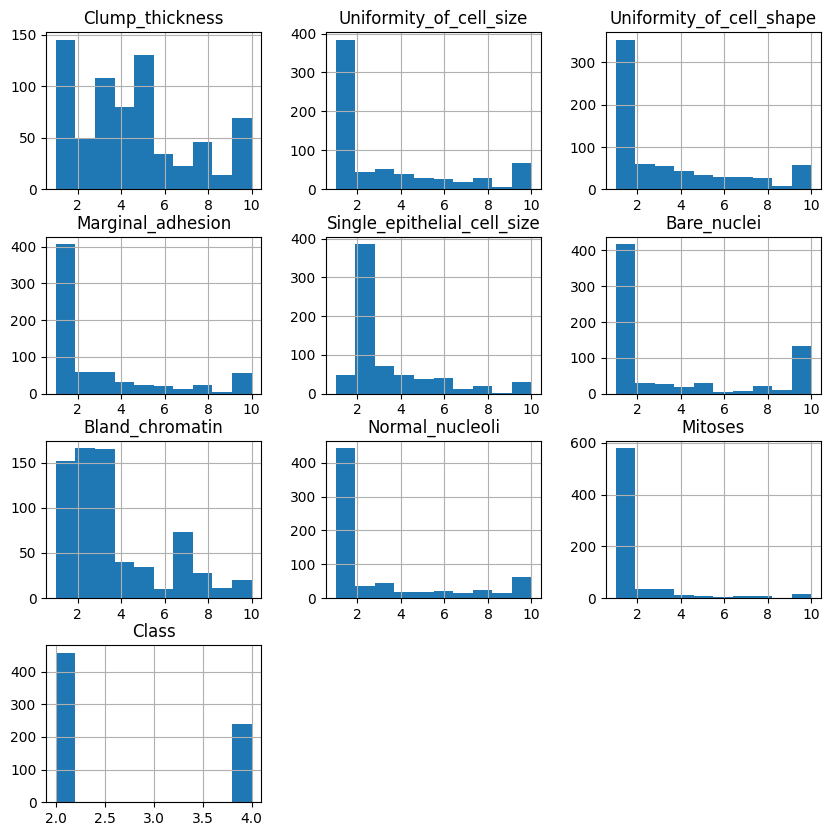

In [98]:
#Gráficos de histogramas
import matplotlib.pyplot as plt
data.hist(figsize=(10,10))
plt.show()

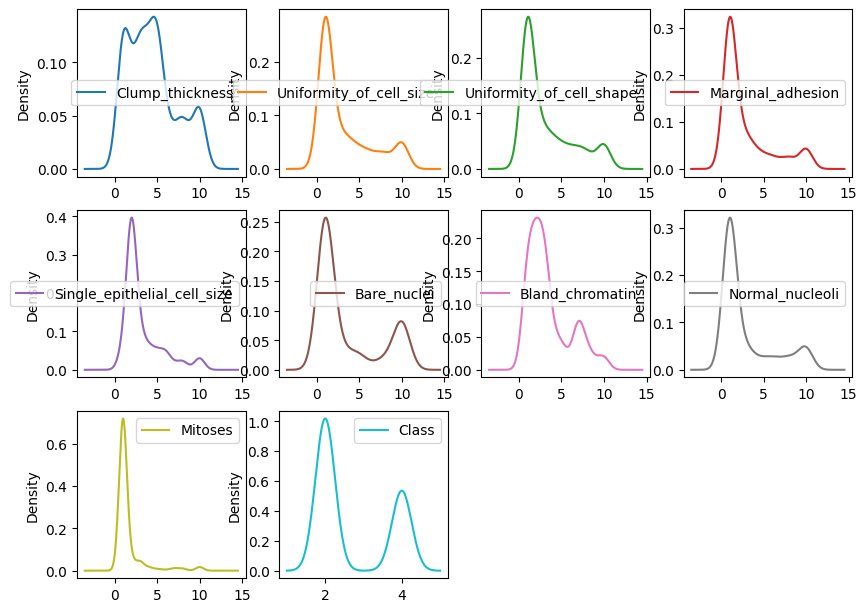

In [99]:
#Gráficos de densidad
data.plot(kind='density', subplots=True, layout=(4,4), sharex=False, figsize=(10,10))
plt.show()

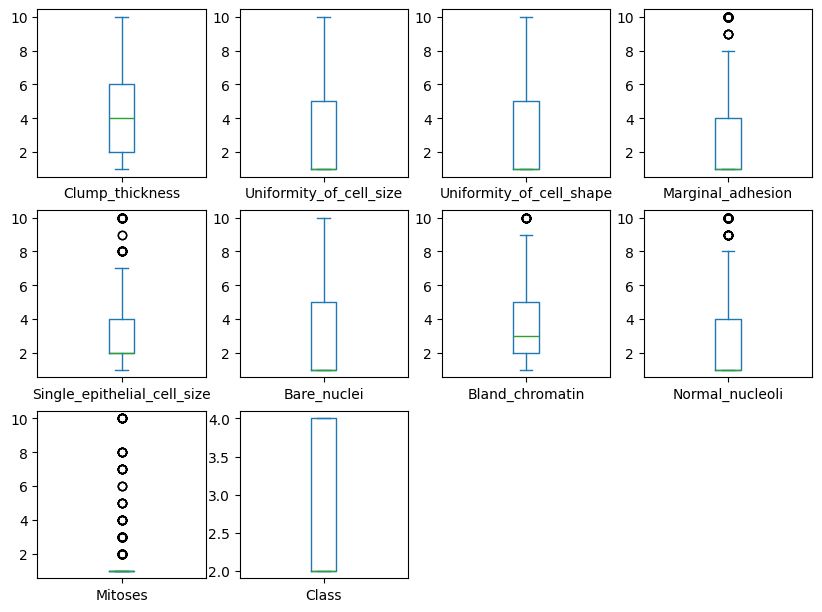

In [100]:
#Box plot
data.plot(kind='box', subplots=True, layout=(4,4), sharex=False, sharey=False, figsize=(10,10))
plt.show()

/usr/local/lib/python3.11/dist-packages/pandas/plotting/_matplotlib/misc.py:96: UserWarning: You passed a edgecolor/edgecolors ('none') for an unfilled marker ('+').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(


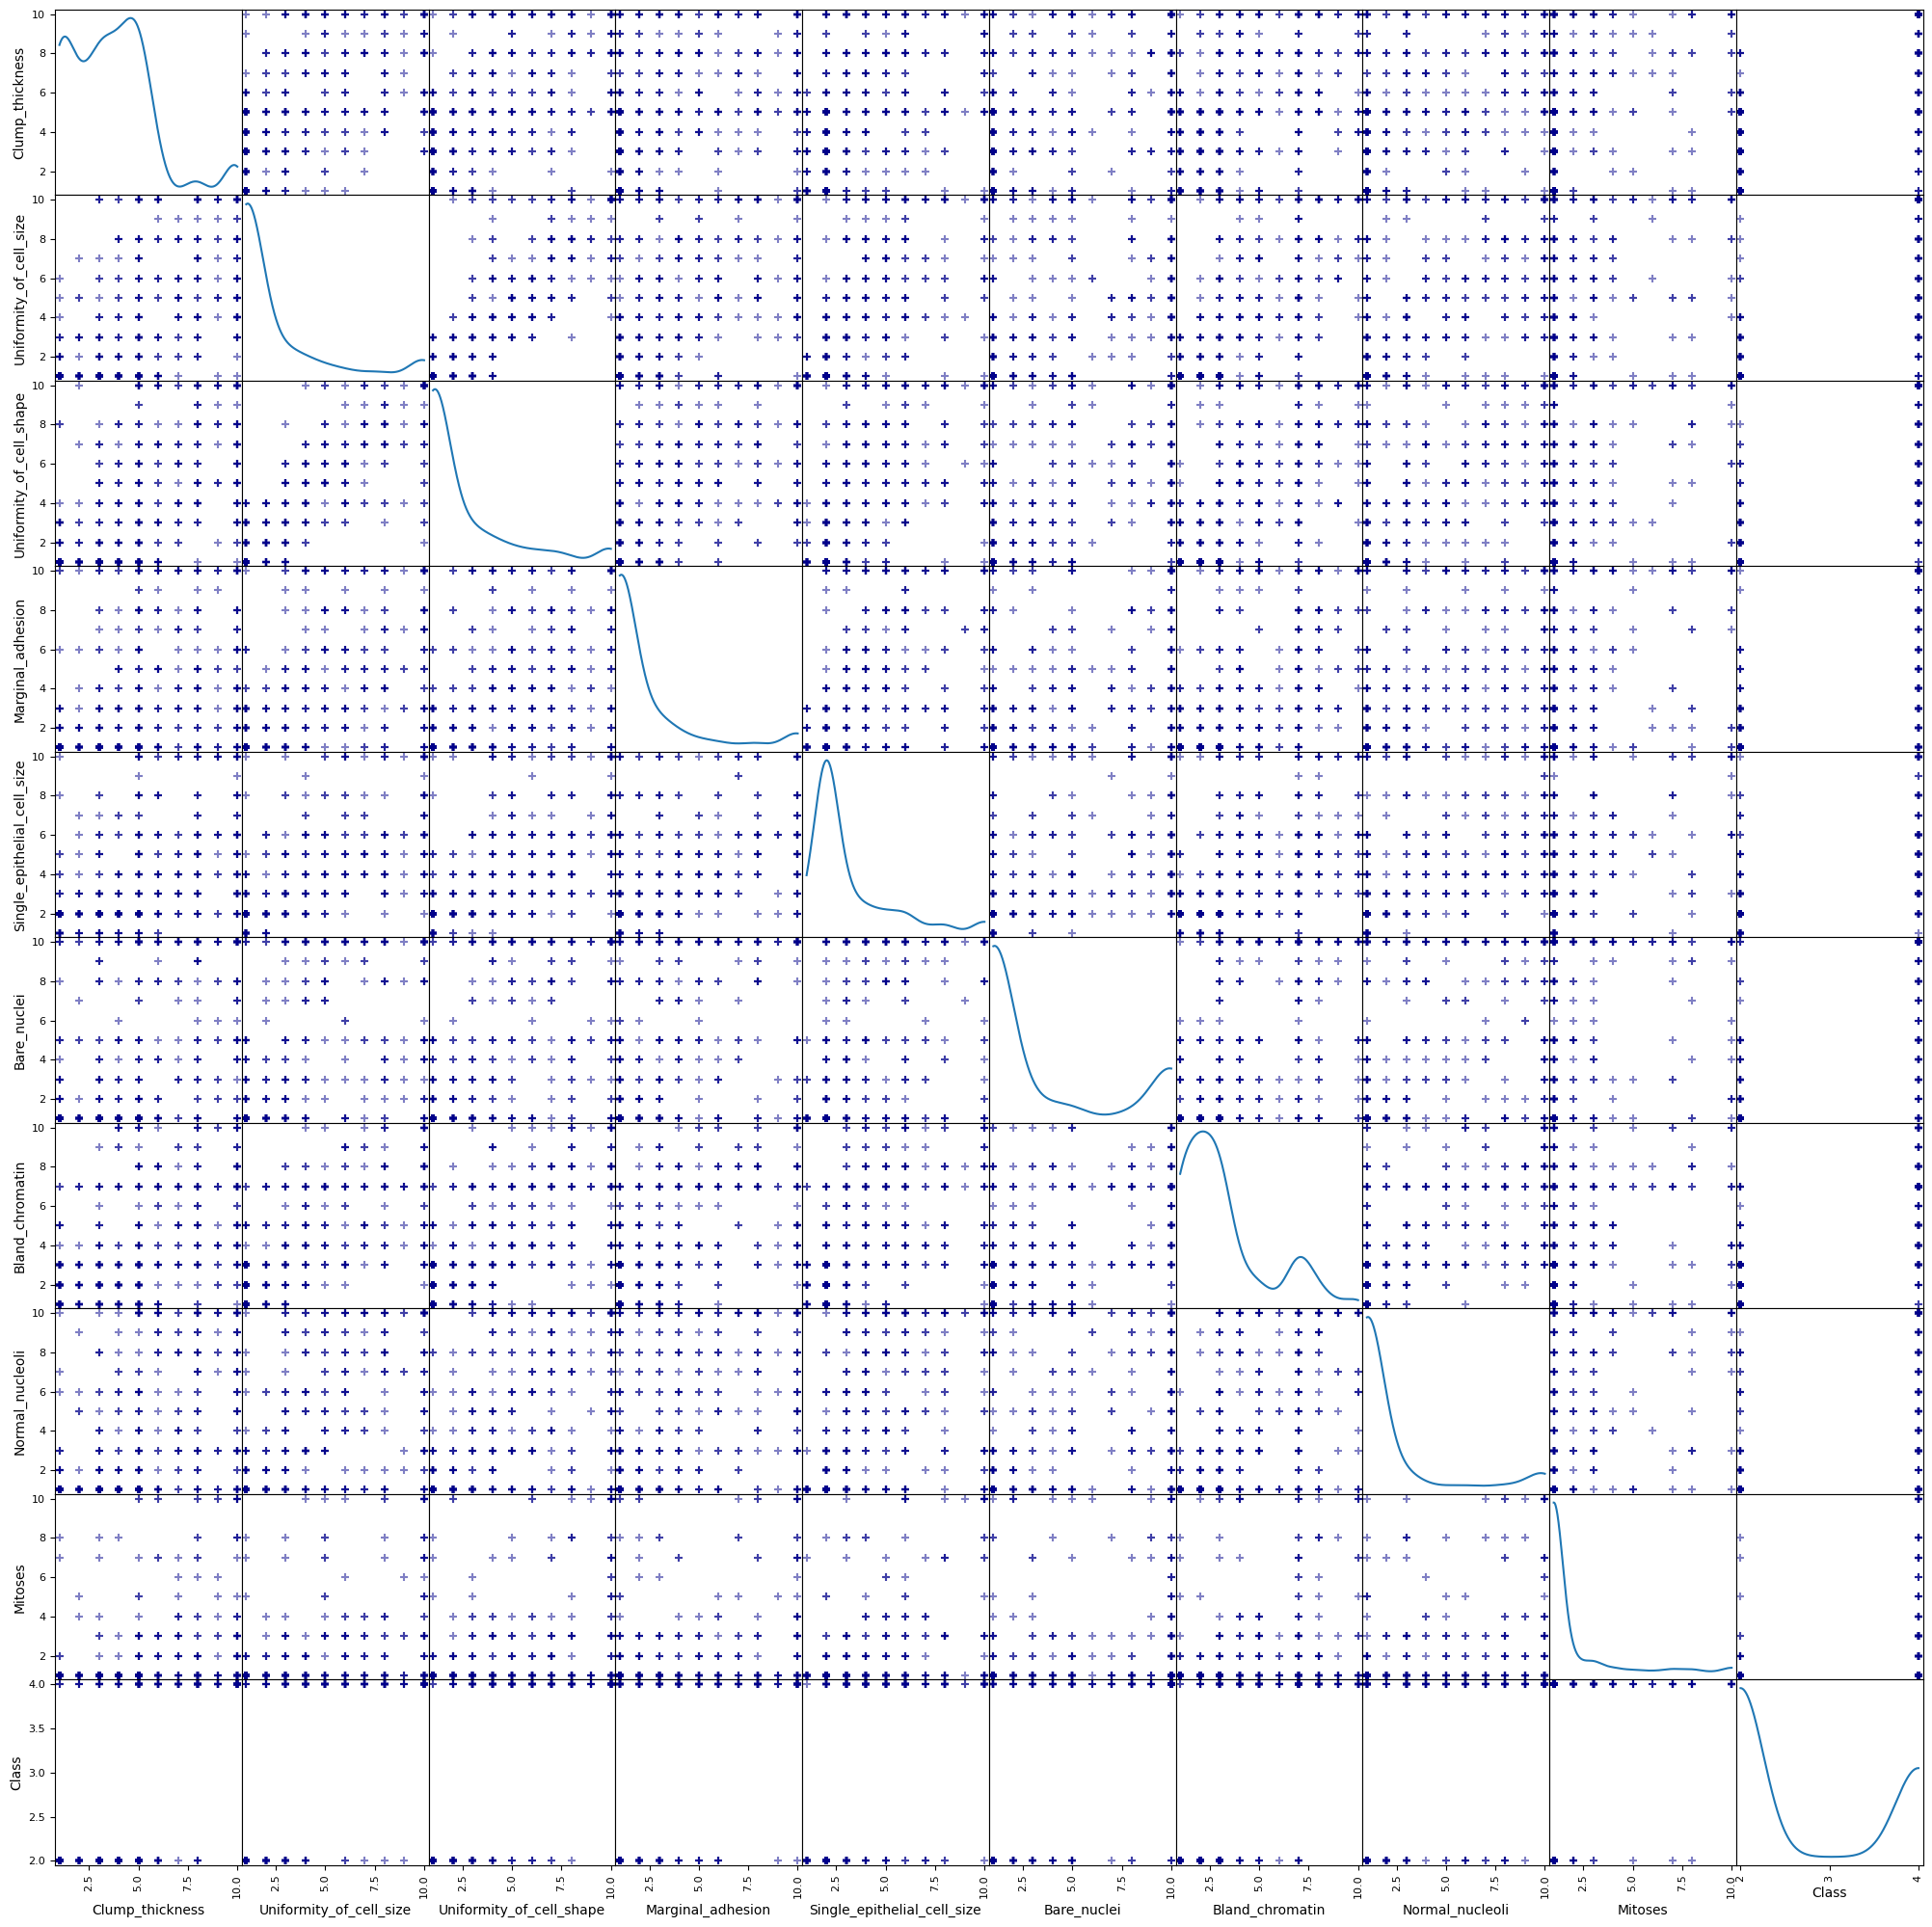

In [101]:
#Diagramas de dispersión
from pandas.plotting import scatter_matrix
scatter_matrix(data, figsize=(25,25), color='darkblue', diagonal="kde", marker='+')
plt.show()

b. Genere el modelo k-NN y determine la cantidad de vecinos más adecuada con el método gráfico
visto en clase. Además, calcule las métricas de clasificación que se implementaron en la parte
práctica e interprete sus resultados más importantes.


In [102]:
#Implementación del modelo k-NN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=2)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=2)

Determinar cantidad de vecinos

In [103]:
#Valores de accuracy para entrenamiento y prueba
import numpy as np
neighbors = np.arange(1, 20)
train_accuracy = np.empty(len(neighbors))
test_accuracy = np.empty(len(neighbors))

for i, k in enumerate(neighbors):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    train_accuracy[i] = knn.score(X_train, y_train)
    test_accuracy[i] = knn.score(X_test, y_test)

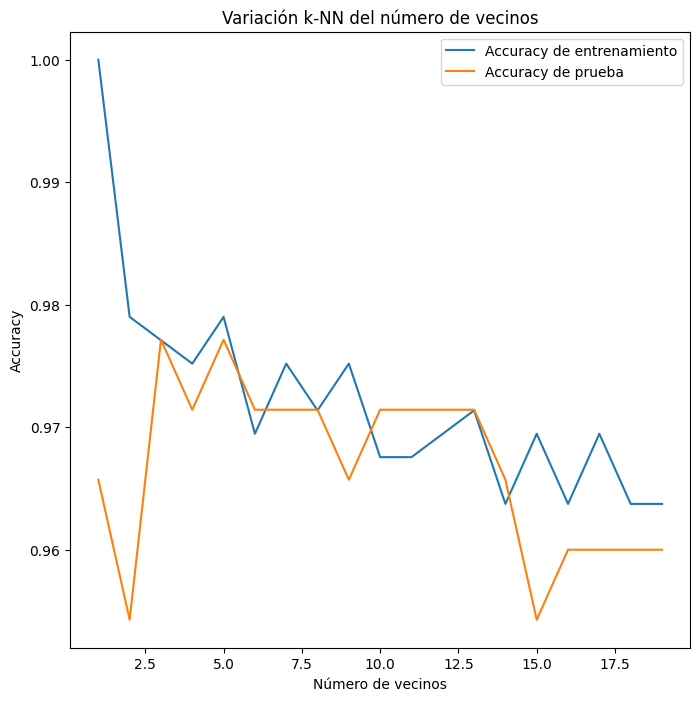

In [104]:
#Generando gráfico de accuracy para entrenamiento y prueba
import matplotlib.pyplot as plt
plt.figure(figsize=(8,8))
plt.title('Variación k-NN del número de vecinos')
plt.plot(neighbors, train_accuracy, label='Accuracy de entrenamiento')
plt.plot(neighbors, test_accuracy, label='Accuracy de prueba')
plt.legend()
plt.xlabel('Número de vecinos')
plt.ylabel('Accuracy')
plt.show()

En base al gráfico, la cantidad de vecinos más adecuada es de 3 vecinos.

In [105]:
#Generando el nuevo modelo k-NN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=3)

In [106]:
#Matriz de confusión
from sklearn.metrics import confusion_matrix
y_pred = knn.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[110,   2],
       [  2,  61]])

In [107]:
#Métricas: Exactitud, precisión, sensibilidad y puntuación F1
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           2       0.98      0.98      0.98       112
           4       0.97      0.97      0.97        63

    accuracy                           0.98       175
   macro avg       0.98      0.98      0.98       175
weighted avg       0.98      0.98      0.98       175



c. Realice un balanceo de clases mediante la técnica SMOTE, vuelva a generar el modelo de
clasificación, calcule sus métricas y compárelas con las del modelo sin balancear para ver si
hubo o no mejoras.

In [108]:
!pip install imbalanced-learn

In [109]:
from imblearn.over_sampling import SMOTE
from collections import Counter
smote = SMOTE(sampling_strategy='minority')
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)
print("Cantidad antes de SMOTE {}".format(Counter(y_train)))
print("Cantidad después de SMOTE {}".format(Counter(y_train_bal)))

Cantidad antes de SMOTE Counter({2: 346, 4: 178})
Cantidad después de SMOTE Counter({4: 346, 2: 346})


<ipython-input-110-a3ef7d69e7bd>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y_train_bal,data=data,palette='hls')


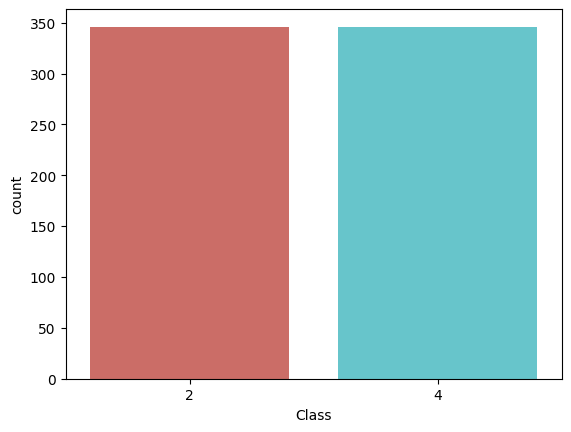

<bound method IndexOpsMixin.value_counts of 0      4
1      2
2      4
3      4
4      2
      ..
687    4
688    4
689    4
690    4
691    4
Name: Class, Length: 692, dtype: int64>


In [110]:
import seaborn as sns
sns.countplot(x=y_train_bal,data=data,palette='hls')
plt.show()
print(y_train_bal.value_counts)

In [111]:
#Generando el nuevo modelo k-NN
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train_bal, y_train_bal)

KNeighborsClassifier(n_neighbors=3)

In [114]:
#Matriz de confusión
from sklearn.metrics import confusion_matrix
y_pred = knn.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[110,   2],
       [  1,  62]])

In [115]:
#Métricas: Exactitud, precisión, sensibilidad y puntuación F1
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           2       0.99      0.98      0.99       112
           4       0.97      0.98      0.98        63

    accuracy                           0.98       175
   macro avg       0.98      0.98      0.98       175
weighted avg       0.98      0.98      0.98       175

